# Figure 2A

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import re

# Input and output paths
input_dir = "data/DLD1"
# save_path = "data/DLD1/event_type_distribution_DLD1.png"

# Define event type grouping
event_grouping = {
    "IR": "IR",
    "IR (overlapping region)": "IR",
    "SES": "Exon Skipping",
    "MES": "Exon Skipping",
    "MXS": "Exon Skipping",
    "TSS|A3SS": "A3SS",
    "TSS|A5SS": "A5SS"
}

# Extract drug concentration and genotype from filenames
def parse_filename(filename):
    match = re.search(r"(g)?(\d+)nm6hr", filename)
    if match:
        genotype = "G579S" if match.group(1) else "WT"
        concentration = f"{match.group(2)}nM"
        return f"{concentration}, {genotype}"
    return None

# Initialize dictionary to store event counts
event_counts = {}

# Process files
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".txt"):
        condition_label = parse_filename(file)
        if condition_label is None:
            continue

        # Read and filter data
        df = pd.read_csv(os.path.join(input_dir, file), sep="\t")
        df_filtered = df[(abs(df["ΔPSI (%)"]) > 20) & (df["T-test p-value"] < 0.01)]
        
        # Map event types and count occurrences
        df_filtered["Grouped Event Type"] = df_filtered["Event Type"].replace(event_grouping)
        df_filtered.to_csv(f"data/DLD1/{condition_label}_Bar_Graph_Data.csv", index=False)
        event_counts[condition_label] = df_filtered["Grouped Event Type"].value_counts()

# Convert to DataFrame and fill missing values with 0
event_counts_df = pd.DataFrame(event_counts).fillna(0)

# Separate IR and Non-IR categories
ir_counts = event_counts_df.loc["IR"] if "IR" in event_counts_df.index else pd.Series(0, index=event_counts_df.columns)
non_ir_counts = event_counts_df.drop(index="IR", errors="ignore")

# Create stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Plot IR as the base bar
ax.barh(ir_counts.index, ir_counts.values, label="IR", color="lightblue", edgecolor='none')

# Plot non-IR categories as a continuous stack
bottom_counts = ir_counts.values
for event_type in non_ir_counts.index:
    ax.barh(
        non_ir_counts.columns, 
        non_ir_counts.loc[event_type], 
        left=bottom_counts, 
        label=event_type, 
        edgecolor='none'
    )
    bottom_counts += non_ir_counts.loc[event_type].values

# Formatting
ax.set_ylabel("Conditions")
ax.set_xlabel("Alternative Splicing Events")
ax.set_title("IR Event Type Distribution in DLD1 (Relative to WT DMSO)")
ax.legend(title="Event Type", loc="upper right")

# Save and show plot
plt.tight_layout()
# plt.savefig(save_path, dpi=300)
plt.show()

# print(f"Figure saved successfully at: {save_path}")


In [ ]:
# Input and output paths
input_dir = "data/MDA-MB-231"
# save_path = "data/MDA-MB-231/event_type_distribution_MDA-MB-231.png"

# Define event type grouping
event_grouping = {
    "IR": "IR",
    "IR (overlapping region)": "IR",
    "SES": "Exon Skipping",
    "MES": "Exon Skipping",
    "MXS": "Exon Skipping",
    "TSS|A3SS": "A3SS",
    "TSS|A5SS": "A5SS"
}

# Extract drug concentration and genotype from filenames
def parse_filename(filename):
    match = re.search(r"(g)?(\d+)nm6hr", filename)
    if match:
        genotype = "G579S" if match.group(1) else "WT"
        concentration = f"{match.group(2)}nM"
        return f"{concentration}, {genotype}"
    return None

# Initialize dictionary to store event counts
event_counts = {}

# Process files
for file in sorted(os.listdir(input_dir)):
    if file.endswith(".txt"):
        condition_label = parse_filename(file)
        if condition_label is None:
            continue

        # Read and filter data
        df = pd.read_csv(os.path.join(input_dir, file), sep="\t")
        df_filtered = df[(abs(df["ΔPSI (%)"]) > 20) & (df["T-test p-value"] < 0.01)]
        
        # Map event types and count occurrences
        df_filtered["Grouped Event Type"] = df_filtered["Event Type"].replace(event_grouping)
        df_filtered.to_csv(f"data/MDA-MB-231/{condition_label}_Bar_Graph_Data.csv", index=False)
        event_counts[condition_label] = df_filtered["Grouped Event Type"].value_counts()

# Convert to DataFrame and fill missing values with 0
event_counts_df = pd.DataFrame(event_counts).fillna(0)

# Separate IR and Non-IR categories
ir_counts = event_counts_df.loc["IR"] if "IR" in event_counts_df.index else pd.Series(0, index=event_counts_df.columns)
non_ir_counts = event_counts_df.drop(index="IR", errors="ignore")

# Create stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Plot IR as the base bar
ax.barh(ir_counts.index, ir_counts.values, label="IR", color="lightblue", edgecolor='none')

# Plot non-IR categories as a continuous stack
bottom_counts = ir_counts.values
for event_type in non_ir_counts.index:
    ax.barh(
        non_ir_counts.columns, 
        non_ir_counts.loc[event_type], 
        left=bottom_counts, 
        label=event_type, 
        edgecolor='none'
    )
    bottom_counts += non_ir_counts.loc[event_type].values

# Formatting
ax.set_ylabel("Conditions")
ax.set_xlabel("Alternative Splicing Events")
ax.set_title("IR Event Type Distribution in DLD1 (Relative to WT DMSO)")
ax.legend(title="Event Type", loc="upper right")

# Save and show plot
plt.tight_layout()
# plt.savefig(save_path, dpi=300)
plt.show()

# print(f"Figure saved successfully at: {save_path}")


# 2C

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import UpSet, from_indicators

# Set modern Seaborn style
sns.set_style("darkgrid")
sns.set_context("talk")  # Bigger fonts for readability

# Define cell lines
cell_lines = ["DLD1", "A375", "CAL51", "MDA-MB-231"]

# Load GO term data
file_paths = {
    "DLD1": "data/DLD1/GO_Biological_Process_2025_table.txt",
    "A375": "data/A375/GO_Biological_Process_2025_table.txt",
    "CAL51": "data/CAL51/GO_Biological_Process_2025_table.txt",
    "MDA-MB-231": "data/MDA-MB-231/GO_Biological_Process_2025_table.txt"
}

# Dictionary to store GO terms with -log10(p-value)
go_terms_dict = {}

for cell_line in cell_lines:
    df = pd.read_csv(file_paths[cell_line], sep="\t")
    
    # Convert Adjusted P-value to numeric and compute -log10(p-value)
    df["Adjusted P-value"] = pd.to_numeric(df["Adjusted P-value"], errors="coerce")
    df["-log10(Adjusted P-value)"] = -np.log10(df["Adjusted P-value"])
    
    # Select top 20 GO terms by p-value
    df_sorted = df.nsmallest(50, "Adjusted P-value")
    
    # Store in dictionary
    for _, row in df_sorted.iterrows():
        term = row["Term"]
        logp = row["-log10(Adjusted P-value)"]
        
        if term not in go_terms_dict:
            go_terms_dict[term] = {"score": 0, "cell_lines": set()}
        
        # Update score and track presence in cell lines
        go_terms_dict[term]["score"] += logp  # Accumulate score
        go_terms_dict[term]["cell_lines"].add(cell_line)

# Convert to DataFrame
terms_df = pd.DataFrame([
    {"GO Term": term, 
     "Weighted Score": info["score"] * len(info["cell_lines"]),  # Apply weighting
     "Num Cell Lines": len(info["cell_lines"])}
    for term, info in go_terms_dict.items()
])

# Sort by Weighted Score
terms_df = terms_df.sort_values(by="Weighted Score", ascending=False)

# ** Improved Bar Plot **
plt.figure(figsize=(14, 8))
cmap = sns.color_palette("magma_r", as_cmap=True)  # Smooth gradient

barplot = sns.barplot(
    data=terms_df.head(30), 
    y="GO Term", x="Weighted Score",  
    edgecolor="black"   # Clean bar edges
)

# **Enhanced Labels and Title**
plt.xlabel("Weighted Significance Value", fontsize=14, fontweight='bold')
plt.ylabel("GO Term", fontsize=14, fontweight='bold')
plt.title("Top Weighted GO Terms Across Cell Lines", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Light grid lines for better readability

output_path = "data/Weighted_GO_Terms.png"
# plt.savefig(output_path, dpi=600, bbox_inches='tight')
# **Show Plot**
plt.show()


In [ ]:
#Only plot top terms of interest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set modern Seaborn style
sns.set_style("darkgrid")
sns.set_context("talk")  # Bigger fonts for readability

# Define cell lines
cell_lines = ["DLD1", "A375", "CAL51", "MDA-MB-231"]

# Load GO term data
file_paths = {
    "DLD1": "data/DLD1/GO_Biological_Process_2025_table.txt",
    "A375": "data/A375/GO_Biological_Process_2025_table.txt",
    "CAL51": "data/CAL51/GO_Biological_Process_2025_table.txt",
    "MDA-MB-231": "data/MDA-MB-231/GO_Biological_Process_2025_table.txt"
}

# Define the top 10 terms of interest
selected_terms = [
    "Gene Expression (GO:0010467)",
    "Cytoplasmic Translation (GO:0002181)",
    "Macromolecule Biosynthetic Process (GO:0009059)",
    "mRNA Splicing, via Spliceosome (GO:0000398)",
    "Regulation of Cell Cycle (GO:0051726)",
    "Cell Cycle G2/M Phase Transition (GO:0044839)",
    "RNA Export From Nucleus (GO:0006405)",
    "Mitotic Sister Chromatid Segregation (GO:0000070)"
]

# Dictionary to store GO terms with -log10(p-value)
go_terms_dict = {}

for cell_line in cell_lines:
    df = pd.read_csv(file_paths[cell_line], sep="\t")
    
    # Convert Adjusted P-value to numeric and compute -log10(p-value)
    df["Adjusted P-value"] = pd.to_numeric(df["Adjusted P-value"], errors="coerce")
    df["-log10(Adjusted P-value)"] = -np.log10(df["Adjusted P-value"])
    
    # Filter only selected GO terms
    df_filtered = df[df["Term"].isin(selected_terms)]
    
    # Store in dictionary
    for _, row in df_filtered.iterrows():
        term = row["Term"]
        logp = row["-log10(Adjusted P-value)"]
        
        if term not in go_terms_dict:
            go_terms_dict[term] = {"score": 0, "cell_lines": set()}
        
        # Update score and track presence in cell lines
        go_terms_dict[term]["score"] += logp  # Accumulate score
        go_terms_dict[term]["cell_lines"].add(cell_line)

# Convert to DataFrame
terms_df = pd.DataFrame([
    {"GO Term": term, 
     "Weighted Score": info["score"] * len(info["cell_lines"]),  # Apply weighting
     "Num Cell Lines": len(info["cell_lines"])}
    for term, info in go_terms_dict.items()
])

# Sort by Weighted Score
terms_df = terms_df.sort_values(by="Weighted Score", ascending=False)

# ** Improved Bar Plot **
plt.figure(figsize=(14, 8))

barplot = sns.barplot(
    data=terms_df,  # Only the selected terms are plotted
    y="GO Term", x="Weighted Score",  
    edgecolor="black"
)

# **Enhanced Labels and Title**
plt.xlabel("Weighted Significance Value", fontsize=14, fontweight='bold')
plt.ylabel("GO Term", fontsize=14, fontweight='bold')
plt.title("Selected GO Terms Across Cell Lines", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Light grid lines for better readability

# output_path = "data/Selected_GO_Terms.png"
# plt.savefig(output_path, dpi=600, bbox_inches='tight')

# **Show Plot**
plt.show()


# 2E

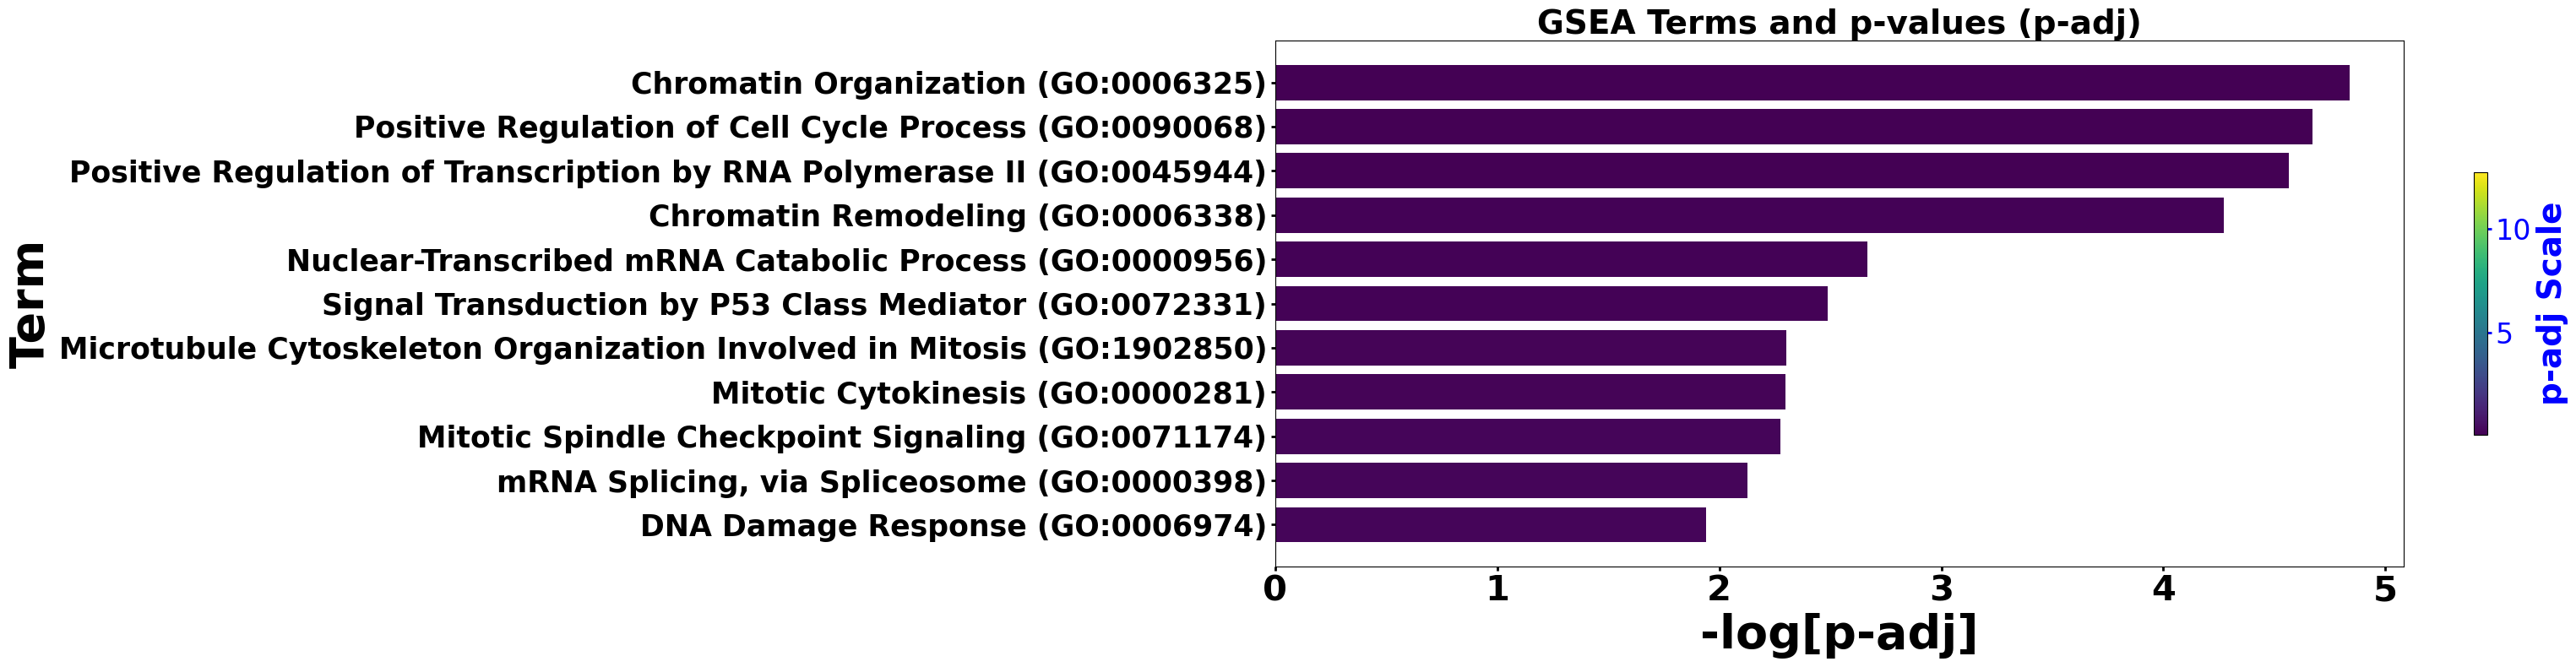

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the CSV file
file_path = "data/Table S6 - Phosphoproteomics.xlsx"
data = pd.read_excel(file_path, sheet_name="Table S6B. GSEA")

# Filter data for FDR values greater than 0.005
#filtered_data = data[data['FDR'] > 0.000005]
filtered_data = data.sort_values(by='Adjusted P-value', ascending=True)

# Extract the relevant columns from filtered data
terms_to_plot = ["Chromatin Organization (GO:0006325)", "Positive Regulation of Cell Cycle Process (GO:0090068)", 
                    "Positive Regulation of Transcription by RNA Polymerase II (GO:0045944)", "Chromatin Remodeling (GO:0006338)",
                    "Nuclear-Transcribed mRNA Catabolic Process (GO:0000956)", "Signal Transduction by P53 Class Mediator (GO:0072331)",
                    "Microtubule Cytoskeleton Organization Involved in Mitosis (GO:1902850)", "Mitotic Cytokinesis (GO:0000281)", "Mitotic Spindle Checkpoint Signaling (GO:0071174)",
                    "mRNA Splicing, via Spliceosome (GO:0000398)", "DNA Damage Response (GO:0006974)"]
plot_data = filtered_data[filtered_data["Term"].isin(terms_to_plot)]

fdr_to_plot = -np.log10(plot_data["Adjusted P-value"])

# Create a horizontal bar plot
fig, ax = plt.subplots(figsize=(32, 8))  # Adjust the size as needed
color_scale = cm.viridis(np.linspace(0, 1, len(terms)))

bars = ax.barh(terms_to_plot, fdr_to_plot, color=color_scale)

# Create a proxy mappable for the colorbar
norm = mcolors.Normalize(vmin=min(fdr_values), vmax=max(fdr_values))
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

# Adjust axis label font size and make it bold
ax.set_xlabel('-log[p-adj]', fontsize=40, fontweight='bold')
ax.set_ylabel('Term', fontsize=40, fontweight='bold')
ax.set_title('GSEA Terms and p-values (p-adj)', fontsize=28, fontweight='bold')

# Make x and y ticks bold
ax.tick_params(axis='x', labelsize=30, labelrotation=0, width=2)
ax.tick_params(axis='y', labelsize=25, labelrotation=0, width=2)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Invert y-axis for better readability
ax.invert_yaxis()

# Add colorbar with bold ticks and label
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5)
cbar.ax.tick_params(labelsize=24, colors='blue', width=2)
cbar.set_label('p-adj Scale', fontsize=28, fontweight='bold', color='blue')

plt.tight_layout()
# plt.savefig('data/GSEA.png', bbox_inches='tight', dpi=300, pad_inches=0.5)
plt.show()
